In [1]:
################################################
## Import Required Libraries and Load Dataset
################################################
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

%matplotlib inline

dataset = pd.read_csv("../config/Algerian_forest_fires_dataset_UPDATE.csv", header=1)
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [2]:
############################
## Data cleaning process
############################

# Check for missing values
dataset[dataset.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [ ]:
############################
## Add Region Labels
############################
# The dataset is converted into two separate datasets,
# one for Bejaia and one for Sidi Bel Abbes.
# and add a new column to identify the location
# Bejaia dataset starts from index 0 to 122, and Sidi Bel Abbes dataset starts from index 122 to
# the end of the dataset
dataset.loc[:122, "Region"] = 0  # 0 for Bejaia
dataset.loc[122:, "Region"] = 1  # 1 for Sidi Bel Abbes
dataset[["Region"]] = dataset[["Region"]].astype(int)  # Convert Region column to integer type
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [4]:
#######################
## Remove Null Rows
#######################
# Remove the null values from the dataset
dataset = dataset.dropna().reset_index(drop=True)
dataset.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0


In [ ]:
###########################################################
## Remove duplicated header row after merging datasets
###########################################################

# because the dataset is merged and 122 index contains header of the second dataset,
# so we need to remove it
dataset = dataset.drop(index=122).reset_index(drop=True)
dataset.iloc[[122]]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
122,01,06,2012,32,71,12,0.7,57.1,2.5,8.2,0.6,2.8,0.2,not fire,1


In [6]:
#############################################
## Remove unwanted spaces from column names
#############################################

# Fix spaces in column names
dataset.columns = dataset.columns.str.strip()
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    str  
 1   month        243 non-null    str  
 2   year         243 non-null    str  
 3   Temperature  243 non-null    str  
 4   RH           243 non-null    str  
 5   Ws           243 non-null    str  
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(1), str(14)
memory usage: 28.6 KB


In [7]:
#################################################
## Convert selected columns to integer datatype
#################################################

cols_to_numeric = ["month", "day", "Temperature", "RH", "Ws"]
dataset[cols_to_numeric] = dataset[cols_to_numeric].astype(int)
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   day          243 non-null    int64
 1   month        243 non-null    int64
 2   year         243 non-null    str  
 3   Temperature  243 non-null    int64
 4   RH           243 non-null    int64
 5   Ws           243 non-null    int64
 6   Rain         243 non-null    str  
 7   FFMC         243 non-null    str  
 8   DMC          243 non-null    str  
 9   DC           243 non-null    str  
 10  ISI          243 non-null    str  
 11  BUI          243 non-null    str  
 12  FWI          243 non-null    str  
 13  Classes      243 non-null    str  
 14  Region       243 non-null    int64
dtypes: int64(6), str(9)
memory usage: 28.6 KB


In [8]:
#################################################
## Change the other columns to float type
#################################################

other_cols = [col for col in dataset.columns if dataset[col].dtype == "str"]
print(other_cols)
for col in other_cols:
    if col != "Classes":
        dataset[col] = dataset[col].astype(float)

dataset.info()

['year', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes']
<class 'pandas.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    float64
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    str    
 14  Region       243 non-null    int64  
dtypes: float64(8), int64(6), str(1)
memory usage: 28.6 KB


In [9]:
##################################################
## Save the cleaned dataset to a new CSV file
##################################################

dataset.to_csv("../config/Algerian_forest_fires_dataset_CLEANED.csv", index=False)
dataset.describe()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Region
count,243.000000,243.000000,243.0,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000,243.000000
mean,15.761317,7.502058,2012.0,32.152263,62.041152,15.493827,0.762963,77.842387,14.680658,49.430864,4.742387,16.690535,7.035391,0.497942
std,8.842552,1.114793,0.0,3.628039,14.828160,2.811385,2.003207,14.349641,12.393040,47.665606,4.154234,14.228421,7.440568,0.501028
min,1.000000,6.000000,2012.0,22.000000,21.000000,6.000000,0.000000,28.600000,0.700000,6.900000,0.000000,1.100000,0.000000,0.000000
25%,8.000000,7.000000,2012.0,30.000000,52.500000,14.000000,0.000000,71.850000,5.800000,12.350000,1.400000,6.000000,0.700000,0.000000
50%,16.000000,8.000000,2012.0,32.000000,63.000000,15.000000,0.000000,83.300000,11.300000,33.100000,3.500000,12.400000,4.200000,0.000000
75%,23.000000,8.000000,2012.0,35.000000,73.500000,17.000000,0.500000,88.300000,20.800000,69.100000,7.250000,22.650000,11.450000,1.000000
max,31.000000,9.000000,2012.0,42.000000,90.000000,29.000000,16.800000,96.000000,65.900000,220.400000,19.000000,68.000000,31.100000,1.000000


### EDA (Exploratory Data Analysis) and Feature Engineering

In [ ]:
# EDA (Exploratory Data Analysis) and Feature Engineering
# EDA means to analyze the dataset and understand the relationships between the features and the
# target variable (Classes in this case).
# We will use seaborn and matplotlib to visualize the relationships between the features and the
# target variable
# Feature engineering means to create new features from the existing features that can help the
# model to learn better. We will create new features based on the existing features and
# the target variable.

##################################################
## Drop Unnecessary Columns
##################################################
# drop the day, month, and year columns as they are not useful for our analysis
dataset_copy = dataset.drop(["day", "month", "year"], axis=1)
dataset_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [11]:
#########################
## Encode Target Class
#########################

# Encode the categorical variable "Classes" into numerical values
dataset_copy["Classes"] = np.where(dataset_copy["Classes"].str.contains("not fire"), 0, 1)
dataset_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,0,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,0,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,0,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,0,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,0,0


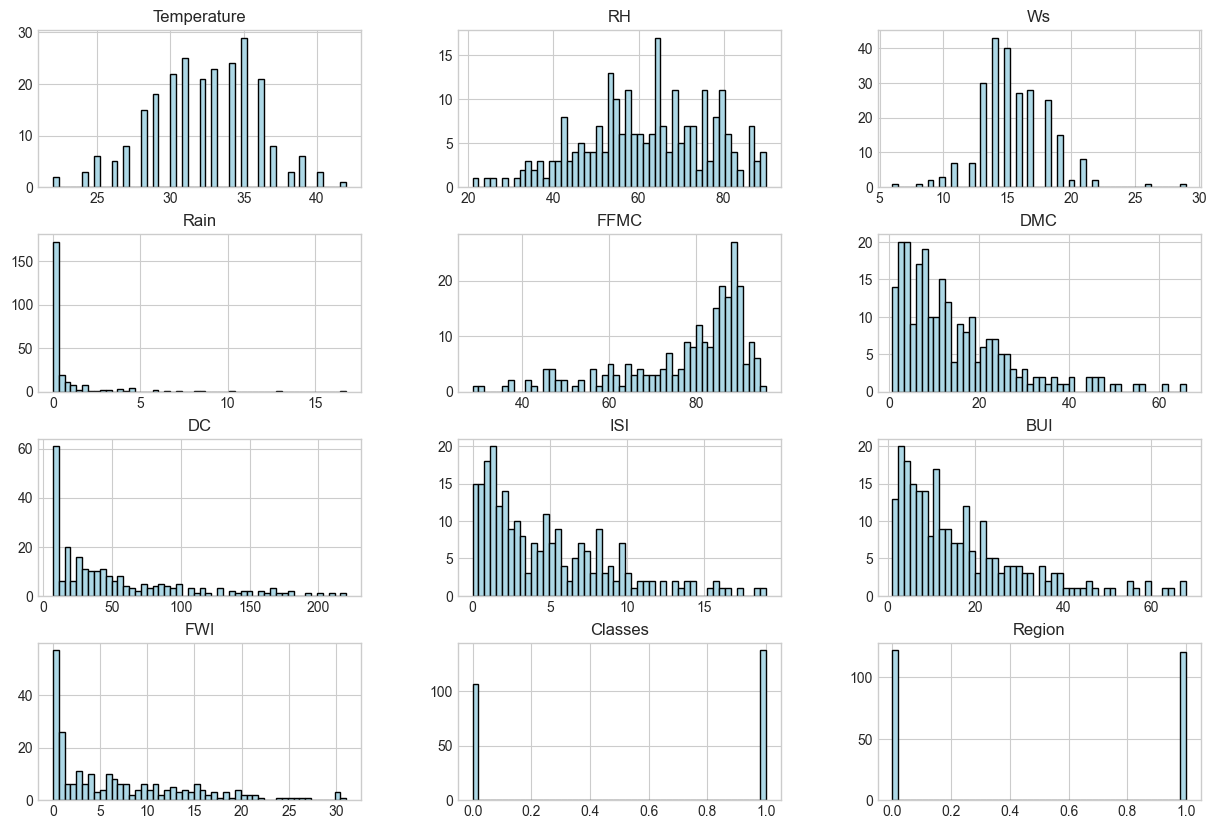

In [12]:
# Plot density plots for all features
plt.style.use("seaborn-v0_8-whitegrid")
dataset_copy.hist(bins=50, figsize=(15, 10), color="lightblue", edgecolor="black")
plt.show()

In [13]:
percentage = dataset_copy["Classes"].value_counts(normalize=True) * 100
print(percentage)

Classes
1    56.378601
0    43.621399
Name: proportion, dtype: float64


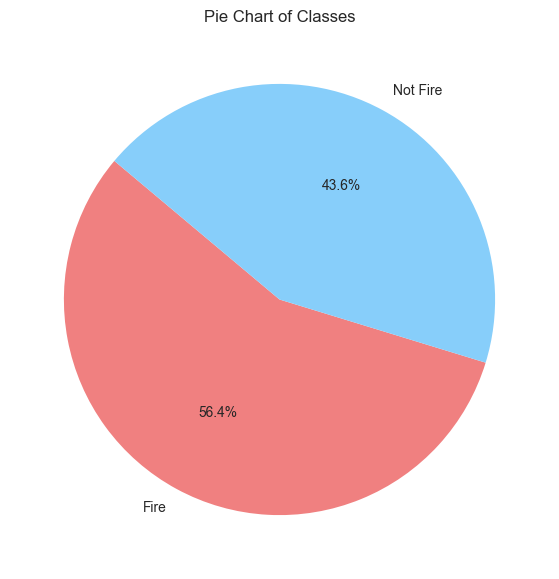

In [14]:
# Percentage for pie chart
class_labels = ["Fire", "Not Fire"]
plt.figure(figsize=(12, 7))
plt.pie(
    percentage,
    labels=class_labels,
    autopct="%1.1f%%",
    startangle=140,
    colors=["lightcoral", "lightskyblue"],
)
plt.title("Pie Chart of Classes")
plt.ylabel("")
plt.show()

Text(0.5, 1.0, 'Correlation Heatmap')

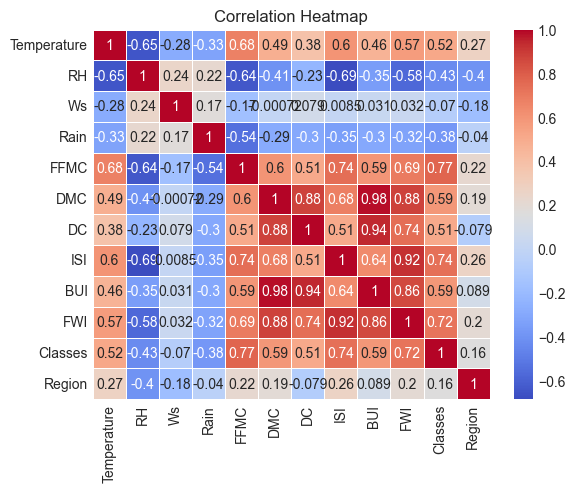

In [15]:
sns.heatmap(dataset_copy.corr(), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap")

<Axes: ylabel='FWI'>

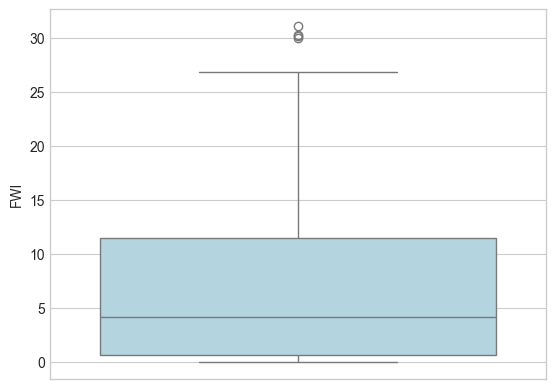

In [16]:
# Box plots for FWI feature
sns.boxplot(dataset_copy["FWI"], color="lightblue")

   day  month    year  Temperature  RH  Ws  Rain  FFMC  DMC    DC  ISI  BUI  \
0    1      6  2012.0           29  57  18   0.0  65.7  3.4   7.6  1.3  3.4   
1    2      6  2012.0           29  61  13   1.3  64.4  4.1   7.6  1.0  3.9   
2    3      6  2012.0           26  82  22  13.1  47.1  2.5   7.1  0.3  2.7   
3    4      6  2012.0           25  89  13   2.5  28.6  1.3   6.9  0.0  1.7   
4    5      6  2012.0           27  77  16   0.0  64.8  3.0  14.2  1.2  3.9   

   FWI  Classes  Region  
0  0.5        0       0  
1  0.4        0       0  
2  0.1        0       0  
3  0.0        0       0  
4  0.5        0       0  


<Axes: xlabel='Region', ylabel='count'>

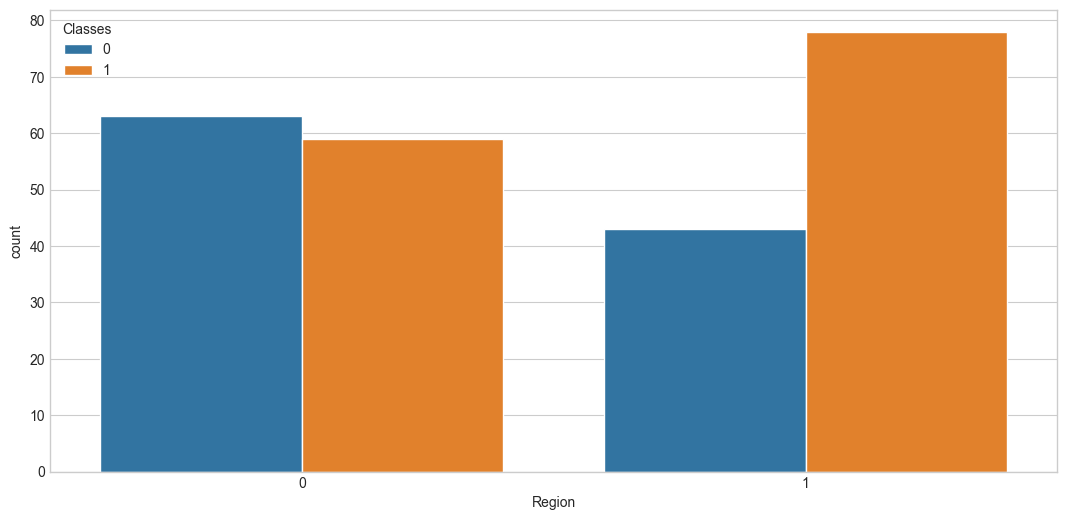

In [17]:
# Important: Region wise fire and not fire distribution
df = dataset.copy()
df.columns = df.columns.str.strip()
df["Classes"] = np.where(df["Classes"].str.contains("not fire"), 0, 1)
print(df.head())
dataset_temp = [
    dataset_copy.loc[dataset_copy["Region"] == 0],
    dataset_copy.loc[dataset_copy["Region"] == 1],
]
plt.figure(figsize=(13, 6))
sns.set_style("whitegrid")
sns.countplot(x="Region", hue="Classes", data=df)

Text(0.5, 0, 'Month')

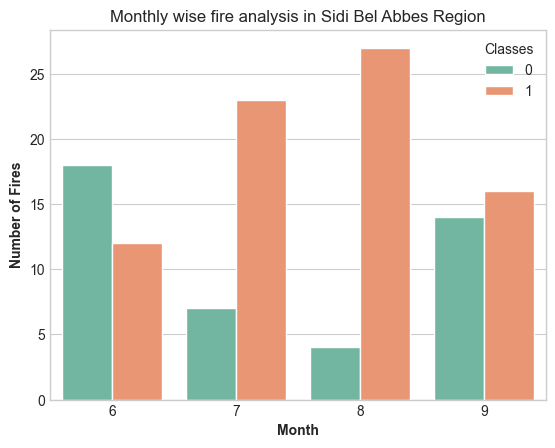

In [18]:
##############################################
## Monthly Fire Distribution (Sidi Bel-Abbes)
##############################################
# Important: Monthly distribution of fires in Sidi Bel Abbes region
df_temp = df.loc[df["Region"] == 1]  # Filter the dataset for Sidi Bel Abbes region
# Plot the countplot for monthly distribution of fires in Sidi Bel Abbes region
sns.countplot(x="month", hue="Classes", data=df_temp, palette="Set2")
plt.title("Monthly wise fire analysis in Sidi Bel Abbes Region")
plt.ylabel("Number of Fires", weight="bold")
plt.xlabel("Month", weight="bold")

Text(0.5, 0, 'Month')

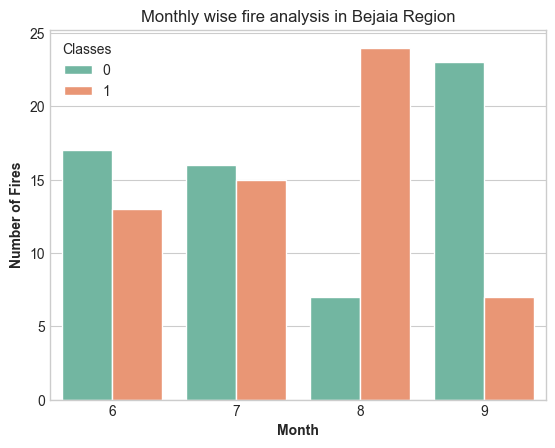

In [19]:
#######################################
## Monthly Fire Distribution (Bejaia)
#######################################

# Important: Monthly distribution of fires in Bejaia region
df_temp = df.loc[df["Region"] == 0]  # Filter the dataset for Bejaia region
# Plot the countplot for monthly distribution of fires in Bejaia region
sns.countplot(x="month", hue="Classes", data=df_temp, palette="Set2")
plt.title("Monthly wise fire analysis in Bejaia Region")
plt.ylabel("Number of Fires", weight="bold")
plt.xlabel("Month", weight="bold")